In [1]:
import numpy as np
import time
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import root

### Build Mesh

In [2]:
def solve_omega_R(R, I_contact, O_contact):
    """Root-finding from: 1 = R + (R/(2*I_contact)) * sum_{e=1}^{2*O_contact} omega^e
    HOW DO WE KNOW THERE IS ONE ROOT?

    Args:
        R (float): contact radius, in (0, 1).
        I_contact (int): number of elements inside the contact radius.
        O_contact (int): number of elements outside the contact radius (= E - I_contact).

    Returns:
        float or None: omega, or None if O_contact == 0 (no outer region, nothing to solve).
    """
    if O_contact == 0:
        return None
    def f(omega):
        s = sum(omega ** e for e in range(1, 2 * O_contact + 1))
        return R + (R / (2 * I_contact)) * s - 1.0
    f1 = f(1.0)
    if f1 == 0.0:
        # ig this is for debugging
        return 1.0
    if f1 < 0.0:
        lo, hi = 1.0, 2.0
        while f(hi) < 0:
            hi *= 2
            if hi > 1e6:
                raise RuntimeError("could not bracket omega (>1 side)")
    else:
        lo, hi = 1e-8, 1.0
        while f(lo) > 0:
            lo /= 2
            if lo < 1e-12:
                raise RuntimeError("could not bracket omega (<1 side) -- R may be infeasible for this I_contact")
    return brentq(f, lo, hi)

In [3]:
def mesh_from_R(R, I_contact, E):
    """Build the full 1-indexed-node mesh array X (length N = 2E+1) from the
    contact radius R alone. Inner nodes (elements 1..I_contact) are evenly spaced across [0, R];
    outer nodes (elements I_contact+1..E) are spaced geometrically by omega(R) out to r=1.

    Args:
        R (float): contact radius, in (0, 1).
        I_contact (int): number of elements inside the contact radius (fixed discretization choice).
        E (int): total number of elements.

    Returns:
        (np.ndarray, float or None): (X, omega) -- X has shape (N,) with X[0] = 0, X[-1] = 1;
        omega is None when O_contact = E - I_contact == 0.
    """
    if R < 1e-12:
        print("Contact Area too small")
        return 
    Outside_contact = E - I_contact
    N = 2 * E + 1
    # spine locations
    X = np.zeros(N)
    # evenly spaced spines inside the contact area
    X[0:2 * I_contact + 1] = np.linspace(0.0, R, 2 * I_contact + 1)
    # calculate increase ratio
    omega = solve_omega_R(R, I_contact, Outside_contact)
    if Outside_contact > 0:
        spine_loc = R
        step_base = R / (2 * I_contact)
        for e in range(1, 2 * Outside_contact + 1):
            spine_loc += step_base * omega ** e
            X[2 * I_contact + e] = spine_loc
    return X, omega

### Basis Functinos

In [4]:
def nodes_from_E(e):
    return [2 * e, 2 * e + 1, 2 * e + 2]

def values_at_E(e, value_vec):
    E1, E2, E3 = nodes_from_E(e)
    return (value_vec[E1], value_vec[E2], value_vec[E3])

In [5]:
def phi_min_1(xi):
    return 0.5 * xi * (xi - 1)

def phi_0(xi):
    return -(xi ** 2) + 1

def phi_plus_1(xi):
    return 0.5 * xi * (xi + 1)

def dphi_min_1(xi):
    return xi - 0.5

def dphi_0(xi):
    return - 2 * xi

def dphi_plus_1(xi):
    return xi + 0.5

PHI = [phi_min_1, phi_0, phi_plus_1]
DPHI = [dphi_min_1, dphi_0, dphi_plus_1]

def drdxi(xi, Xe):
    X1, X2, X3 = Xe
    return X1 * DPHI[0](xi) + X2 * DPHI[1](xi) + X3 * DPHI[2](xi)

def r_of_E(xi, Xe):
    X1, X2, X3 = Xe
    return X1 * PHI[0](xi) + X2 * PHI[1](xi) + X3 * PHI[2](xi)

### Integrals

In [6]:
# initialize integration for gaussian quadrature
XI_G, W_G = np.polynomial.legendre.leggauss(5)   # should be accurate enough for I_xixi

def gauss(f):
    return np.dot(W_G, f(XI_G))   

In [7]:
def Int_I_j(Xe_kp1, i, j):
    
    f = lambda xi: PHI[i](xi) * PHI[j](xi) * drdxi(xi, Xe_kp1)
    return gauss(f)

def Int_I_xi(Xe_kp1, Xe_k, del_t, i, j):
    
    def vel_sum(xi):
        return sum((((Xe_kp1[m] - Xe_k[m])/del_t) * PHI[m](xi))for m in range(3))
    
    f = lambda xi: vel_sum(xi) * PHI[i](xi) * DPHI[j](xi)
    return gauss(f)

def Int_I_xixi(Xe_kp1, i, j):
    
    f = lambda xi: DPHI[j](xi) * (DPHI[i](xi) * 1/drdxi(xi, Xe_kp1) - PHI[i](xi)/(r_of_E(xi, Xe_kp1)))
    return gauss(f)

def Int_I(Xe_kp1, i):
    
    f = lambda xi: PHI[i](xi) * drdxi(xi, Xe_kp1)
    return gauss(f)

### Building Vec

In [8]:
def residuals(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, X_kp1, X_k, del_t, E, We, Fr, Ra):
    
    res_eta_vec = np.zeros(2 * E + 1)
    res_u_vec = np.zeros(2 * E + 1)
    
    for ele in range(E):
        
        Xe_k = values_at_E(ele, X_k)
        Xe_kp1 = values_at_E(ele, X_kp1)
                                
        alpha_k_e = values_at_E(ele, alpha_k)
        alpha_kp1_e = values_at_E(ele, alpha_kp1)
                                
        beta_k_e = values_at_E(ele, beta_k)
        beta_kp1_e = values_at_E(ele, beta_kp1)
                                
        gamma_kp1_e = values_at_E(ele, gamma_kp1)
        
        ele_nodes = nodes_from_E(ele)
        
        
        for local_i in range(3):
            
            for j in range(3):
                I_j = Int_I_j(Xe_kp1, local_i, j)
                I_xi = Int_I_xi(Xe_kp1, Xe_k, del_t, local_i, j)
                        
                res_eta_vec[ele_nodes[local_i]] += ((alpha_kp1_e[j] - alpha_k_e[j] - del_t * beta_kp1_e[j]) * I_j 
                                                    - del_t * (alpha_kp1_e[j] * I_xi )) 
                    
                res_u_vec[ele_nodes[local_i]] += ((beta_kp1_e[j] - beta_k_e[j] + del_t * gamma_kp1_e[j]) * I_j 
                                                    - del_t * beta_kp1_e[j] * I_xi)
                
                # additional outside the pressed area
                if ele >= I:
                    I_xixi = Int_I_xixi(Xe_kp1, local_i, j)
                    res_u_vec[ele_nodes[local_i]] += del_t/We * alpha_kp1_e[j] * I_xixi
                    
                    # adding DR term for phi = 2I+1 (1-indexing)
                    if ele == I:
                        if local_i == 0:
                            res_u_vec[ele_nodes[local_i]] += del_t * PHI[local_i](-1)/ We * alpha_kp1_e[j] * DPHI[j](-1) * 1 / drdxi(-1, Xe_kp1)
                            
            # additional inside the pressed area                    
            if ele < I:
                res_u_vec[ele_nodes[local_i]] -= (2 * del_t) / (We * Ra) * Int_I(Xe_kp1, local_i)
                        
                
                
            res_u_vec[ele_nodes[local_i]] += del_t * Int_I(Xe_kp1, local_i) / Fr
            
                
    # changing last equation for alpha
    res_eta_vec[-1] = alpha_kp1[-1]
                        
    # adding boundary term & co to last 
    res_u_vec[-1] = beta_kp1[-1]
            
    return res_eta_vec, res_u_vec

In [9]:
def v_vec(gamma_kp1, v_k, v_kp1, X_kp1, del_t, I, Fr, m):
    
    pressure_cont = 0 
    
    for ele in range(I):
        Xe_kp1 = values_at_E(ele, X_kp1)
        gamma_e = values_at_E(ele, gamma_kp1)
        
        for j in range(3):
            f = lambda xi: PHI[j](xi) * r_of_E(xi, Xe_kp1) * drdxi(xi, Xe_kp1)
            pressure_cont += gamma_e[j] * gauss(f)
            
    return v_kp1 - v_k + del_t * ((1/Fr) - 2 * (np.pi/m) * pressure_cont)

In [10]:
def build_vec(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, 
                h_k, h_kp1, v_k, v_kp1, X_kp1, X_k, 
                del_t, E, I, We, Fr, Ra, m):
    
    R_kp1 = X_kp1[2*I]
    
    res = residuals(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, X_kp1, X_k, del_t, E, We, Fr, Ra)
    
    pres_outside_contact = gamma_kp1[2*I+1:]
    
    contact_cond = np.zeros(2 * I + 1)
    for j in range(2 * I + 1):
        contact_cond[j] = h_kp1 - Ra * np.cos(np.arcsin((j * R_kp1)/(2 * I * Ra))) - alpha_kp1[j]
        
    # getting values for first non-contact element
    alpha_kp1_e = values_at_E(I, alpha_kp1)
    X_kp1_e = values_at_E(I, X_kp1)
    tangent_cond = np.array([np.tan(np.arcsin(R_kp1/Ra)) - 1/(drdxi(-1, X_kp1_e)) * sum((alpha_kp1_e[j] * DPHI[j](-1)) for j in range(3))])
    
    vertical_vel_vec = np.zeros((2))
    vertical_vel_vec[0] = h_kp1 - h_k - del_t * v_kp1            
    vertical_vel_vec[1] = v_vec(gamma_kp1, v_k, v_kp1, X_kp1, del_t, I, Fr, m)
    
    return np.concatenate([*res, pres_outside_contact, contact_cond, tangent_cond, vertical_vel_vec])

### Building Jacobian

In [11]:
def dresidual(X_k, X_kp1, del_t, E, I, We):
    N = 2*E + 1
    dReta_dalpha = np.zeros((N, N))
    dReta_dbeta = np.zeros((N, N))        
    dReta_dgamma = np.zeros((N, N))
        
        
    dRu_dalpha = np.zeros((N, N))
    dRu_dbeta = np.zeros((N, N))
    dRu_dgamma = np.zeros((N, N))
        
    for ele in range(E):
        Xe_k = values_at_E(ele, X_k)
        Xe_kp1 = values_at_E(ele, X_kp1)
        nodes_ele = nodes_from_E(ele)
            
        for i in range(3):
            for j in range(3):
                I_j = Int_I_j(Xe_kp1, i, j)
                I_xi = Int_I_xi(Xe_kp1, Xe_k, del_t, i, j)
                    
                dReta_dalpha[nodes_ele[i], nodes_ele[j]] += I_j - del_t * I_xi
                dReta_dbeta[nodes_ele[i], nodes_ele[j]] += I_j
                
                
                dRu_dbeta[nodes_ele[i], nodes_ele[j]]  += I_j - del_t * I_xi
                dRu_dgamma[nodes_ele[i], nodes_ele[j]] += I_j
                                    
                    
                if ele >= I:
                    I_xixi = Int_I_xixi(Xe_kp1, i, j)
                    dRu_dalpha[nodes_ele[i], nodes_ele[j]] += del_t * I_xixi / We
                
                # adding derivative of Dr; right side
                if ele == I and i == 0:
                    dRu_dalpha[nodes_ele[i], nodes_ele[j]] += del_t / We * DPHI[j](-1) * 1/drdxi(-1, Xe_kp1)
                    
    dReta_dbeta *= -del_t
    dRu_dgamma *= del_t    
    
    # since last residual in eta is simple alpha_N, need to adjust derivatives
    dReta_dalpha[-1], dReta_dbeta[-1] = 0, 0
    dReta_dalpha[-1, -1] = 1
    
    # last residual in u contains an extra term
    dRu_dalpha[-1], dRu_dbeta[-1] = 0, 0
    dRu_dbeta[-1, -1] = 1
    
    return dReta_dalpha, dReta_dbeta, dReta_dgamma, dRu_dalpha, dRu_dbeta, dRu_dgamma

In [12]:
def dresidual_R(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, X_k, X_kp1, del_t, I, E, We, Fr, Ra, eps=1e-6):
    
    R_kp1 = X_kp1[2*I]
    
    def resid(R):
        X_kp1, _ = mesh_from_R(R, I, E)
        eta_R, u_R = residuals(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, X_kp1, X_k, del_t, E, We, Fr, Ra)
        return eta_R, u_R
        
    R_plus = R_kp1 + eps
    eta_R_plus, u_R_plus = resid(R_plus)
    
    R_minus = R_kp1 - eps
    eta_R_minus, u_R_minus = resid(R_minus)
    
    return (eta_R_plus - eta_R_minus)/(2*eps), (u_R_plus - u_R_minus)/(2*eps)

In [13]:
def dcontact(R_kp1, I, E, Ra):
    
    O = E - I
    N = 2 * E + 1
    
    dcontact_dalpha = np.hstack((-1*np.eye(2*I+1), np.zeros((2*I+1, 2*O))))
    dcontact_dR = np.zeros((2*I+1, 1))
    
    for i in range(2*I+1):
        numerator = Ra * (i)**2 * R_kp1
        denominator = 4 * (I * Ra)**2 * np.sqrt(1 - ((i* R_kp1) **2/(4 * (I * Ra)**2)))
        
        dcontact_dR[i] = numerator / denominator
    
    return np.hstack((dcontact_dalpha, np.zeros((2*I+1, 2*N)), np.ones((2*I+1, 1)), np.zeros((2*I+1, 1)), dcontact_dR))

In [14]:
def dtangent(X_kp1, alpha_kp1, I, E, Ra, eps = 1e-6):
    
    Xe_kp1 = values_at_E(I, X_kp1) 
    R_kp1 = X_kp1[2*I]
    O = E - I
    N = 2 * E + 1
    
    alpha_kp1_e = values_at_E(I, alpha_kp1)
    dxidr = 1/(drdxi(-1, Xe_kp1))
    
    
    # derivative with respect to alpha
    center = np.array([[-DPHI[j](-1.0) * dxidr for j in range(3)]])
    dtangent_dalpha = np.hstack(((np.zeros((1, 2*I)), center, np.zeros((1, 2*O-2)))))


    # calculating deta/dr from outside (mesh-dependent)
    def deta_dr_outer(X_R):
        Xe = values_at_E(I, X_R)
        return sum(alpha_kp1_e[j] * DPHI[j](-1.0) for j in range(3)) / drdxi(-1.0, Xe)

    def f(R):
        X_R, _ = mesh_from_R(R, I, E)
        return np.tan(np.arcsin(R / Ra)) - deta_dr_outer(X_R)

    dtangent_dr = (f(R_kp1 + eps) - f(R_kp1 - eps)) / (2 * eps)
    
    return np.hstack((dtangent_dalpha, np.zeros((1, 2 * N + 2)), [[dtangent_dr]]))

In [15]:
def dvel(gamma_kp1, X_kp1, del_t, E, I, Fr, m, eps=1e-6):
    
    N = 2 * E + 1
    R_kp1 = X_kp1[2*I]
    
    dv_gamma = np.zeros(N)
    
    for ele in range(I):
        Xe_kp1 =  values_at_E(ele, X_kp1)
        nodes_e = nodes_from_E(ele)
        
        for j in range(3):
            f = lambda xi: PHI[j](xi) * r_of_E(xi, Xe_kp1) *  drdxi(xi, Xe_kp1)
            dv_gamma[nodes_e[j]] += gauss(f)
            
    dv_gamma *= -del_t * (2 * np.pi / m)
    

    def v(R):
        X_kp1, _ = mesh_from_R(R, I, E)
        v_of_R = v_vec(gamma_kp1, 0, 0, X_kp1, del_t, I, Fr, m)
        return v_of_R
    
    v_R_plus = v(R_kp1 + eps)
    v_R_min = v(R_kp1 - eps)
    dv_R = (v_R_plus - v_R_min)/(2 * eps)
    
    return np.concatenate([np.zeros(2*N), dv_gamma, [0], [1], [dv_R]])
        

In [16]:
def Jacobian(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, X_k, X_kp1, del_t, I, E, We, Fr, Ra, m):
    
    O = E - I
    N = 2 * E + 1
    
    # Residual Derivatives
    dReta_dalpha, dReta_dbeta, dReta_dgamma, dRu_dalpha, dRu_dbeta, dRu_dgamma = dresidual(X_k, X_kp1, del_t, E, I, We)
    d_eta_r, d_u_r = dresidual_R(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, X_k, X_kp1, del_t, I, E, We, Fr, Ra)
    
    dReta = np.hstack((dReta_dalpha, dReta_dbeta, dReta_dgamma, np.zeros((N, 2)), d_eta_r.reshape(-1, 1)))
    dRu = np.hstack((dRu_dalpha, dRu_dbeta, dRu_dgamma, np.zeros((N, 2)), d_u_r.reshape(-1, 1)))
    
    
    # Pressure derivatives
    dgamma = np.hstack((np.zeros((2 * O, 2 * N + 2 * I + 1)), np.eye(2*O), np.zeros((2*O, 3))))
    
    
    #contact derivatives
    R_kp1 = X_kp1[2*I]
    dcon = dcontact(R_kp1, I, E, Ra)
    
    
    # tangent derivative
    dtan = dtangent(X_kp1, alpha_kp1, I, E, Ra)
    
    
    # vertical fall derivatives
    dh = np.hstack((np.zeros((1, 3*N)), np.array([[1, -del_t]]), np.zeros((1,1))))
    dv = dvel(gamma_kp1, X_kp1, del_t, E, I, Fr, m)
    
    
    J = np.vstack((dReta, dRu, dgamma, dcon, dtan, dh, dv))
    
    return J

### Solver

In [17]:
def unflatten(x_vec, N):
    alpha_kp1 = x_vec[0:N]
    beta_kp1  = x_vec[N:2 * N]
    gamma_kp1 = x_vec[2 * N:3 * N]
    h_kp1 = x_vec[3 * N]
    v_kp1 = x_vec[3 * N + 1]
    R_kp1 = x_vec[-1]
    # print("unflatten: Done with unflattening")
    return alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1

In [ ]:
def solve_system(x0_vec, del_t, E, I, We, Fr, Ra, m, accept_tol=1e-12):

        
    N = 2 * E + 1
    x0_flat = np.asarray(x0_vec).flatten().copy()
    alpha_k, beta_k, gamma_k, h_k, v_k, R_k = unflatten(x0_flat, N)
    X_k, _ = mesh_from_R(R_k, I, E)

    def F_flat(xi):
        alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
        X_kp1, _ = mesh_from_R(R_kp1, I, E)
        return build_vec(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, 
                h_k, h_kp1, v_k, v_kp1, X_kp1, X_k, 
                del_t, E, I, We, Fr, Ra, m)

    def J_flat(xi):
        alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
        X_kp1, _ = mesh_from_R(R_kp1, I, E)
        return Jacobian(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1,
                X_k, X_kp1, del_t, I, E, We, Fr, Ra, m)      

    try:
        sol = root(F_flat, x0_flat, jac=J_flat, method='hybr', options={'xtol': 1e-12})
                
        resid_max = np.max(np.abs(F_flat(sol.x)))

        if sol.success and resid_max < accept_tol:      # both must hold
            return sol.x
        
    except RuntimeError as e:
        print(f"solve_system: raised: {e}")

    print("solve_system: Did not converge, dt =", del_t)                     
    return False

### Running Simulation

In [ ]:
# Initial Parameters
Ra = 0.2 # must be less than 1
v_bar = 6.5*1e-3
We = 0.1
# CONVERT v_bar to weber for comparison
Fr = 3.9
m = 1

E = 10        # small mesh
N = 2 * E + 1
I = 5

# time variables
dt = 0.001
T_end = 2
t_list = np.arange(0, T_end, dt)
t_idx = 0
max_halvings_total = 100
halvings_done = 0

# initial area guess
h_freefall = Ra - dt * v_bar
intersec_angle = np.arccos(h_freefall/Ra)
horizontal_intersec = Ra * np.sin(intersec_angle)
R0 = horizontal_intersec/2

# initial mesh
x0_vec = np.concatenate([np.zeros(3*N), [Ra, -v_bar, R0]])
#print(x0_vec)
X0, _ = mesh_from_R(R0, I, E)

# initialize storing arrays
all_xs = [x0_vec]
all_ts = [0.0]

In [ ]:
print(f"Running: E={E} N={N} I={I} dt0={dt} T_end={T_end}")

while t_idx < (len(t_list) - 1) and halvings_done < max_halvings_total:
    print("⏰ Index: ", t_idx)
    del_t = t_list[t_idx + 1] - t_list[t_idx]
    if del_t < 1e-12:
        break
    x_k = all_xs[-1]
    
    if t_idx == 0:
        # adapt initial area guess when halving the timestep
        h_freefall = Ra - del_t * v_bar
        intersec_angle = np.arccos(h_freefall/Ra)
        horizontal_intersec = Ra * np.sin(intersec_angle)
        R0 = horizontal_intersec/2
        x_k[-1] = R0
        
    a, b, g, h, v, R = unflatten(x_k, N)
    print("h, v, R    =", h, v, R)

    result =  solve_system(x0_vec, del_t, E, I, We, Fr, Ra, m)
    
    if result is False:
        t_insert = (t_list[t_idx + 1] + t_list[t_idx]) / 2
        t_list = np.insert(t_list, t_idx + 1, t_insert)
        halvings_done += 1
        print(f"  step {t_idx}: FAILED, halving dt -> inserted t={t_insert:.4f}")
    else:
        all_xs.append(result)
        all_ts.append(t_list[t_idx + 1])
        t_idx += 1
        a, b, g, h, v, R = unflatten(result, N)
        #print(f"  step {t_idx}/{len(t_list)-1}: t={all_ts[-1]:.4f} h={h:.4f} v={v:.4f} R={R:.4f}", flush=True)

print(f"Done. {len(all_xs)} accepted states, {halvings_done} halvings.")

Running: E=10 N=21 I=5 dt0=0.001 T_end=2
⏰ Index:  0
h, v, R    = 0.2 -0.006500000000000001 0.0008062192242187093
⏰ Index:  1
h, v, R    = 0.19999324382885958 -0.0067561711404435995 0.0009265448779586727
⏰ Index:  2
h, v, R    = 0.1999862316673702 -0.007012161489377483 0.0012463101030026126
⏰ Index:  3
h, v, R    = 0.19997896365101825 -0.007268016351951988 0.001433323731045321
⏰ Index:  4
h, v, R    = 0.1999714399139399 -0.007523737078349455 0.0015917138971137
⏰ Index:  5
h, v, R    = 0.19996366058802226 -0.007779325917635108 0.0017337481321295207
⏰ Index:  6
h, v, R    = 0.19995562580475776 -0.008034783264494798 0.0018643893246265476
⏰ Index:  7
h, v, R    = 0.19994733569504958 -0.00829010970818069 0.001985711095563073
⏰ Index:  8
h, v, R    = 0.1999387903874918 -0.008545307557778976 0.00209789891353339
⏰ Index:  9
h, v, R    = 0.19992999000606573 -0.008800381426065994 0.0022005054193450914
⏰ Index:  10
h, v, R    = 0.19992093466836833 -0.009055337697414751 0.00229345524631754
⏰ Index

TypeError: cannot unpack non-iterable NoneType object

### Animations

In [21]:
all_xs_arr = np.array(all_xs)
all_ts_arr = np.array(all_ts)

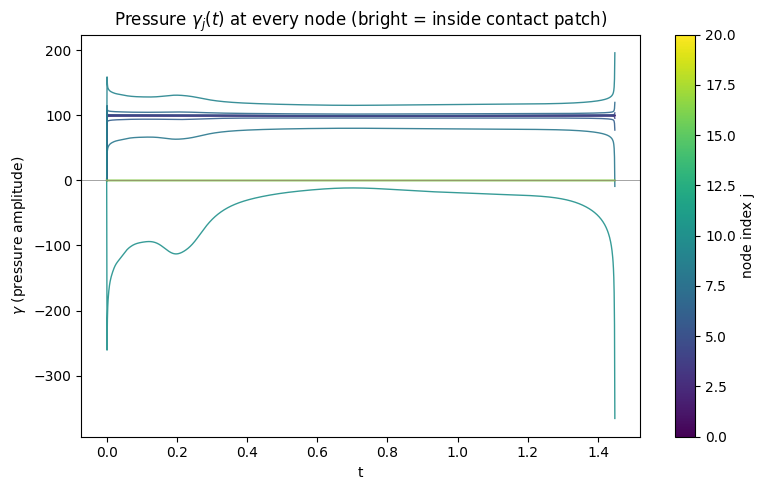

saved pressure_amplitudes.png


In [22]:
gamma_hist = np.array([unflatten(x, N)[2] for x in all_xs_arr])   # shape (num_steps, N)

fig2, ax2 = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
for node in range(N):
    color = cmap(node / (N - 1))
    ax2.plot(all_ts_arr, gamma_hist[:, node], color=color, lw=1,
              alpha=0.9 if node <= 2 * I else 0.3)  # contact-zone nodes emphasized

ax2.axhline(0, color="gray", lw=0.5)
ax2.set_xlabel("t")
ax2.set_ylabel(r"$\gamma$ (pressure amplitude)")
ax2.set_title(r"Pressure $\gamma_j(t)$ at every node (bright = inside contact patch)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, N - 1))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax2)
cbar.set_label("node index j")

fig2.tight_layout()
fig2.savefig("pressure_amplitudes.png", dpi=150)
plt.show()
print("saved pressure_amplitudes.png")

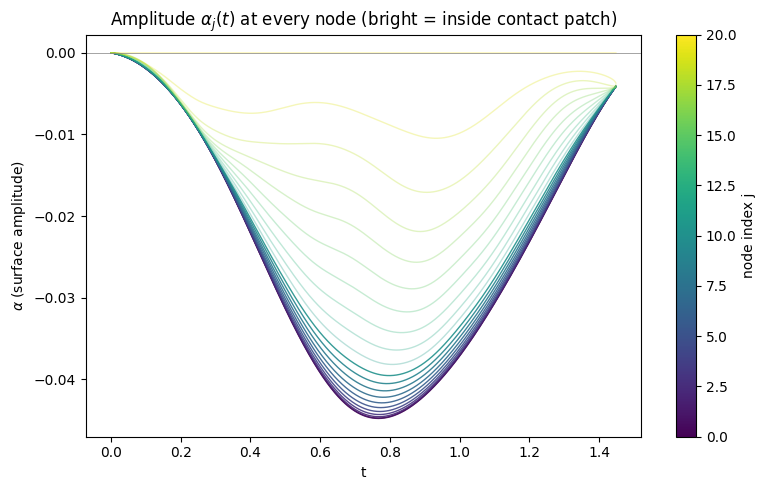

saved pressure_amplitudes.png


In [23]:
alpha_hist = np.array([unflatten(x, N)[0] for x in all_xs_arr])   # shape (num_steps, N)

fig2, ax2 = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
for node in range(N):
    color = cmap(node / (N - 1))
    ax2.plot(all_ts_arr, alpha_hist[:, node], color=color, lw=1,
              alpha=0.9 if node <= 2 * I else 0.3)  # contact-zone nodes emphasized

ax2.axhline(0, color="gray", lw=0.5)
ax2.set_xlabel("t")
ax2.set_ylabel(r"$\alpha$ (surface amplitude)")
ax2.set_title(r"Amplitude $\alpha_j(t)$ at every node (bright = inside contact patch)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, N - 1))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax2)
cbar.set_label("node index j")

fig2.tight_layout()
fig2.savefig("pressure_amplitudes.png", dpi=150)
plt.show()
print("saved pressure_amplitudes.png")

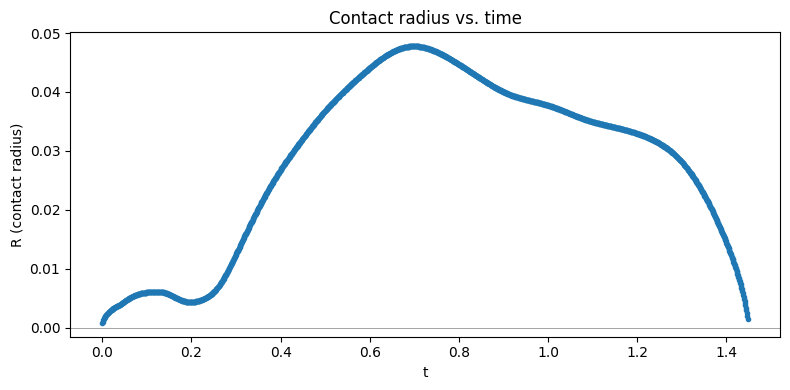

saved R_vs_time.png


In [24]:
import numpy as np
import matplotlib.pyplot as plt

R_hist = np.array([unflatten(x, N)[5] for x in all_xs])   # unflatten returns (a,b,g,h,v,R)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_ts, R_hist, "o-", color="tab:blue", ms=3, lw=1.5)
ax.set_xlabel("t")
ax.set_ylabel("R (contact radius)")
ax.set_title("Contact radius vs. time")
ax.axhline(0, color="gray", lw=0.5)
fig.tight_layout()
fig.savefig("R_vs_time.png", dpi=150)
plt.show()
print("saved R_vs_time.png")

In [ ]:
SUBFRAMES = 4  # linear interpolation between saved steps, for smoother playback
frames = []
for k in range(len(all_xs_arr) - 1):
    a0, b0, g0, h0, v0, R0 = unflatten(all_xs_arr[k], N)
    a1, b1, g1, h1, v1, R1 = unflatten(all_xs_arr[k + 1], N)
    t0, t1 = all_ts_arr[k], all_ts_arr[k + 1]
    for s in range(SUBFRAMES):
        f = s / SUBFRAMES
        a = (1 - f) * a0 + f * a1
        h = (1 - f) * h0 + f * h1
        R = (1 - f) * R0 + f * R1
        t = (1 - f) * t0 + f * t1
        X, _ = mesh_from_R(R, I, E)
        frames.append((t, X, a, h, R))
a_last, h_last, R_last = unflatten(all_xs_arr[-1], N)[0], unflatten(all_xs_arr[-1], N)[3], unflatten(all_xs_arr[-1], N)[5]
frames.append((all_ts_arr[-1], mesh_from_R(R_last, I, E)[0], a_last, h_last, R_last))

fig, ax = plt.subplots(figsize=(6, 6))
membrane_line, = ax.plot([], [], "b-", lw=2, label=r"membrane $\eta(r)$")
sphere_patch = plt.Circle((0, 0), Ra, facecolor="lightsteelblue", edgecolor="navy",
                            lw=1.5, alpha=0.85, zorder=5)
ax.add_patch(sphere_patch)
contact_marker, = ax.plot([], [], "ko", ms=4, zorder=6)
title_txt = ax.set_title("")

all_alpha_max = max(np.max(np.abs(f[2])) for f in frames)
all_h = [f[3] for f in frames]
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(min(min(all_h) - Ra, -all_alpha_max) - 0.05, max(max(all_h) + Ra, all_alpha_max) + 0.05)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("r"); ax.set_ylabel("z")
ax.legend(loc="upper right")
ax.set_xlim(-0.25, 0.25)
ax.set_ylim(-0.05, 0.05)
ax.axhline(0, color="gray", lw=0.5)

def update(frame):
    t, X, a, h, R = frame
    r_full = np.concatenate([-X[::-1], X])
    a_full = np.concatenate([a[::-1], a])
    membrane_line.set_data(r_full, a_full)
    sphere_patch.center = (0, h)
    contact_marker.set_data([-R, R], [np.interp(R, X, a)] * 2)
    title_txt.set_text(f"t = {t:.4f}   h = {h:.4f}   R = {R:.4f}")
    return membrane_line, sphere_patch, contact_marker, title_txt

ani = animation.FuncAnimation(fig, update, frames=frames, blit=False, interval=1000 / 20)
ani.save("impact_simulation.mp4", writer="ffmpeg", fps=200, dpi=120)
plt.close(fig)
print("saved impact_simulation.mp4")

In [ ]:
# def solve_system_og(x0_vec, del_t, E, I, We, Fr, Ra, t_idx, m, 
#                     tol=1e-10, max_it=200, verbose_timing=True, accept_tol=1e-6):
    
#     N = 2 * E + 1
#     # previous timestep's guess
#     x0_flat = np.asarray(x0_vec).flatten().copy()
#     alpha_k, beta_k, gamma_k, h_k, v_k, R_k = unflatten(x0_flat, N)
#     X_k, _ = mesh_from_R(R_k, I, E)

#     def F_flat(xi):
#         alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
#         X_kp1, _ = mesh_from_R(R_kp1, I, E)
#         out = build_vec(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1, 
#                 h_k, h_kp1, v_k, v_kp1, X_kp1, X_k, 
#                 del_t, E, I, We, Fr, Ra, m)
        
#         # checking for infinite values
#         if not np.all(np.isfinite(out)):
#             bad = np.where(~np.isfinite(out))[0]
#             msg = (
#                 "NON-FINITE at trial point:\n"
#                 f"  alpha_kp1 max|.|: {np.max(np.abs(alpha_kp1))}\n"
#                 f"  beta_kp1  max|.|: {np.max(np.abs(beta_kp1))}\n"
#                 f"  gamma_kp1 max|.|: {np.max(np.abs(gamma_kp1))}\n"
#                 f"  h_kp1, v_kp1, R_kp1: {h_kp1}, {v_kp1}, {R_kp1}\n"
#                 f"  non-finite entries of residual at indices: {bad}\n"
#                 f"  residual values there: {out[bad]}"
#             )
#             raise RuntimeError(msg)
#         return out

#     def J_flat(xi):
#         alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
#         X_kp1, _ = mesh_from_R(R_kp1, I, E)
#         return Jacobian(alpha_k, alpha_kp1, beta_k, beta_kp1, gamma_kp1,
#                 X_k, X_kp1, del_t, I, E, We, Fr, Ra, m)      

#     # --- Bounded least_squares: keeps R strictly inside (0, Ra) during the search ---
#     lb = np.full(3 * N + 3, -np.inf)
#     ub = np.full(3 * N + 3, np.inf)
#     lb[-1] = 1e-6               # CHANGED: R = 0 breaks the mesh
#     ub[-1] = Ra * (1 - 1e-6)    # CHANGED: R = Ra gives tan(pi/2) = inf

#     # least_squares requires x0 to be strictly inside the bounds
#     x0_bounded = x0_flat.copy()
#     x0_bounded[-1] = min(max(x0_bounded[-1], lb[-1]), ub[-1])

#     t0 = time.perf_counter()
#     try:
#         ls_result = least_squares(
#             F_flat, x0_bounded, jac=J_flat, bounds=(lb, ub),
#             x_scale='jac',          # CHANGED: rescale unknowns (gamma ~ 1e3, alpha and R ~ 1e-3)
#             xtol=tol, ftol=tol, gtol=tol,
#             max_nfev=max_it,        # CHANGED: at most max_it evaluations, so stuck steps fail fast
#         )
#         elapsed = time.perf_counter() - t0
#         # resid_max = np.max(np.abs(ls_result.fun))

#         # --- scale the residual rows so the acceptance test is relative ---
#         f = ls_result.fun.copy()
#         _, _, _, _, _, R_sol = unflatten(ls_result.x, N)
#         X_sol, _ = mesh_from_R(R_sol, I, E)

#         M = np.zeros(N)                         # lumped mass: integral of phi_i over the mesh
#         for e in range(E):
#             Xe = values_at_E(e, X_sol)
#             nd = nodes_from_E(e)
#             for i in range(3):
#                 M[nd[i]] += Int_I(Xe, i)
#         M[-1] = 1.0                             # last rows are just alpha_N and beta_N

#         f[:N]      /= M                         # eta rows  -> displacement error
#         f[N:2*N]   /= M * del_t                 # u rows    -> acceleration error
#         resid_max = np.max(np.abs(f))

#         if verbose_timing:
#             print(f"solve_system:  [least_squares] success={ls_result.success}  nfev={ls_result.nfev}  "
#                     f"time={elapsed:.3f}s  resid_max={resid_max:.3e}  dt={del_t:.3e}")   # CHANGED: del_t

#         if resid_max < accept_tol:  # CHANGED: accept when the equations are satisfied
#             return ls_result.x
#     except RuntimeError as e:
#         print(f"solve_system: [least_squares] raised: {e}")

#     print("solve_system: Did not converge, dt =", del_t)                      # CHANGED: del_t
#     return False